In [ ]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import numpy as np

In [4]:
# Télécharger population si pas déjà présent
if not os.path.exists("data/raw/population_communes.xlsx"):
    from src.fetch_population import download_population
    download_population()

# Télécharger élections si pas déjà présent
if not os.path.exists("data/raw/elections_legislatives.xlsx"):
    from src.fetch_elections import download_elections
    download_elections()

# Télécharger élections 1er tour
if not os.path.exists("data/raw/elections_t1_legislatives.xlsx"):
    from src.fetch_elections_t1 import download_elections
    download_elections()

Téléchargement en cours : https://static.data.gouv.fr/resources/elections-legislatives-des-30-juin-et-7-juillet-2024-resultats-definitifs-du-1er-tour/20240711-075030/resultats-definitifs-par-communes.xlsx
✔️ Fichier téléchargé avec succès : data/raw/elections_t1_legislatives.xlsx


In [11]:
# --- 1. CONFIGURATION ---
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'

def preparer_donnees_completes():
    # A. CHARGEMENT (Avec le bon encodage utf-8)
    print(f"Chargement du fichier {FILE_PATH}...")
    df_raw = pd.read_excel(FILE_PATH,dtype=str)
    print(f"Dimensions initiales : {df_raw.shape}")
    
    # B. TRANSFORMATION (Wide -> Long)
    # C'est l'étape clé pour ton fichier "à rallonge"
    print("Transformation du fichier (Pivotage des colonnes candidats)...")
    
    # On prépare une liste pour stocker les morceaux
    pieces = []
    
    # On identifie combien de colonnes 'Nuance candidat X' existent
    # On regarde jusqu'à 200 candidats potentiels (largeur max)
    cols_fixes = ['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits', 'Exprimés']
    
    for i in range(1, 200):
        col_nuance = f'Nuance candidat {i}'
        col_voix = f'Voix {i}'
        
        # Si la colonne n'existe plus, on arrête

        if col_nuance not in df_raw.columns:
            break
            
        # On prend juste ce morceau (Commune + Candidat i)
        temp = df_raw[cols_fixes + [col_nuance, col_voix]].copy()
        temp.columns = cols_fixes + ['Nuance', 'Voix'] # On renomme pour standardiser
        
        # On nettoie les lignes vides (pas de candidat n°X dans cette commune)
        temp = temp.dropna(subset=['Nuance'])
        pieces.append(temp)
    
    # On recolle tous les morceaux les uns sous les autres
    df_long = pd.concat(pieces, ignore_index=True)
    
    # C. NETTOYAGE DES CHIFFRES
    df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)
    df_long['Exprimés'] = pd.to_numeric(df_long['Exprimés'], errors='coerce').fillna(0)

    # D. APPLICATION DES 4 BLOCS
    print("Création des blocs politiques...")
    
    def attribuer_bloc_precis(nuance):
        # Gauche NFP
        if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
        # Centre
        elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
        # Droite Républicaine (Le 4ème bloc)
        elif nuance in ['LR', 'DVD']: return 'DROITE'
        # Extrême Droite
        elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
        else: return 'AUTRE'

    df_long['BLOC'] = df_long['Nuance'].apply(attribuer_bloc_precis)
    
    # E. AGREGATION FINALE PAR COMMUNE
    print("Calcul des scores finaux...")
    df_final = df_long.pivot_table(
        index=['Code département', 'Libellé département', 'Code commune', 'Libellé commune'],
        columns='BLOC',
        values='Voix',
        aggfunc='sum'
    ).fillna(0).reset_index()
    
    # Calcul des pourcentages
    colonnes_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']
    df_final['Total_Calcule'] = df_final[colonnes_blocs].sum(axis=1)
    
    # On évite la division par zéro
    df_final = df_final[df_final['Total_Calcule'] > 0].copy()
    
    for bloc in ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE']:
        df_final[f'Pct_{bloc}'] = (df_final[bloc] / df_final['Total_Calcule']) * 100

    return df_final

# --- EXECUTION ---
df_communes = preparer_donnees_completes()

print("\n--- RÉSULTAT FINAL ---")
display(df_communes.head())
print(f"Nombre de communes traitées : {len(df_communes)}")

# Cela va t'afficher (Nombre de lignes, Nombre de colonnes)
print(df_communes.shape) 

# Tu devrais voir environ (34900, 15) -> Ce qui veut dire que tu as bien toute la France !

Chargement du fichier data/raw/elections_t1_legislatives.xlsx...
Dimensions initiales : (35232, 1854)
Transformation du fichier (Pivotage des colonnes candidats)...
Création des blocs politiques...
Calcul des scores finaux...

--- RÉSULTAT FINAL ---


BLOC,Code département,Libellé département,Code commune,Libellé commune,AUTRE,CENTRE,DROITE,EXTREME_DROITE,GAUCHE_NFP,Total_Calcule,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE
0,1,Ain,1001,L'Abergement-Clémenciat,2.0,86.0,47.0,258.0,83.0,476.0,17.436975,18.067227,9.873950,54.201681
1,1,Ain,1002,L'Abergement-de-Varey,1.0,19.0,45.0,42.0,64.0,171.0,37.426901,11.111111,26.315789,24.561404
2,1,Ain,1004,Ambérieu-en-Bugey,94.0,789.0,989.0,2208.0,1810.0,5890.0,30.730051,13.395586,16.791171,37.487267
3,1,Ain,1005,Ambérieux-en-Dombes,15.0,198.0,61.0,494.0,173.0,941.0,18.384697,21.041445,6.482465,52.497343
4,1,Ain,1006,Ambléon,2.0,22.0,3.0,24.0,14.0,65.0,21.538462,33.846154,4.615385,36.923077


Nombre de communes traitées : 35229
(35229, 14)


1. Chargement et préparation des données...
2. Attribution des blocs politiques...
3. Classification des communes...
4. Génération du graphique complet...


C:\Users\anton\AppData\Local\Temp\ipykernel_13980\2012917457.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_graph = df_communes.groupby('Categorie_Taille')[cols_to_plot].mean()


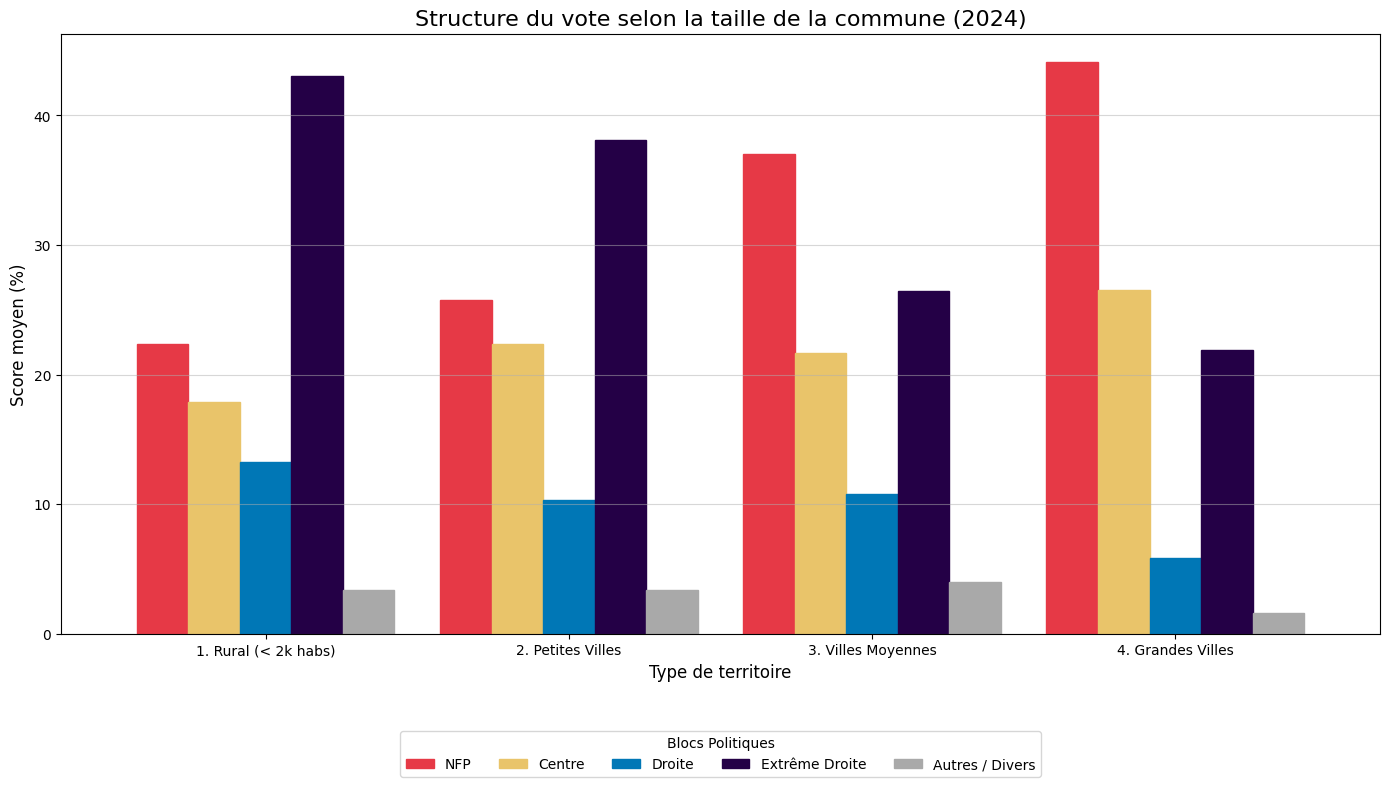


--- RÉSULTATS CHIFFRÉS (Somme = 100%) ---


BLOC,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
Categorie_Taille,,,,,
1. Rural (< 2k habs),22.4,17.9,13.3,43.1,3.4
2. Petites Villes,25.8,22.4,10.3,38.1,3.4
3. Villes Moyennes,37.0,21.7,10.8,26.5,4.0
4. Grandes Villes,44.1,26.5,5.8,21.9,1.6



Vérification somme ligne 1 : 100.0 %


In [12]:
# --- 2. CONFIGURATION ---
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'

def tout_analyser_avec_autre():
    print("1. Chargement et préparation des données...")
    df_raw = pd.read_excel(FILE_PATH,dtype=str)
    # Transformation Wide -> Long
    pieces = []
    cols_fixes = ['Code département', 'Code commune', 'Libellé commune', 'Inscrits']
    
    for i in range(1, 100):
        col_nuance = f'Nuance candidat {i}'
        col_voix = f'Voix {i}'
        if col_nuance not in df_raw.columns: break
        
        temp = df_raw[cols_fixes + [col_nuance, col_voix]].copy()
        temp.columns = ['Code_dep', 'Code_commune', 'Nom_commune', 'Inscrits', 'Nuance', 'Voix']
        temp = temp.dropna(subset=['Nuance'])
        pieces.append(temp)
    
    df_long = pd.concat(pieces, ignore_index=True)
    
    # Nettoyage chiffres
    df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)
    df_long['Inscrits'] = pd.to_numeric(df_long['Inscrits'], errors='coerce').fillna(0)

    # --- 3. ATTRIBUTION DES BLOCS ---
    print("2. Attribution des blocs politiques...")
    def get_bloc(nuance):
        if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
        elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
        elif nuance in ['LR', 'DVD']: return 'DROITE'
        elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
        else: return 'AUTRE' # Les petits candidats, régionalistes, etc.

    df_long['BLOC'] = df_long['Nuance'].apply(get_bloc)
    
    # Agrégation
    df_communes = df_long.pivot_table(
        index=['Code_commune', 'Nom_commune', 'Inscrits'],
        columns='BLOC',
        values='Voix',
        aggfunc='sum'
    ).fillna(0).reset_index()

    # Calcul des %
    cols_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']
    df_communes['Total'] = df_communes[cols_blocs].sum(axis=1)
    df_communes = df_communes[df_communes['Total'] > 0].copy()
    
    for bloc in cols_blocs:
        df_communes[f'Pct_{bloc}'] = (df_communes[bloc] / df_communes['Total']) * 100

    # --- 4. CLASSIFICATION ---
    print("3. Classification des communes...")
    bins = [0, 1500, 15000, 75000, 10000000]
    labels = ['1. Rural (< 2k habs)', '2. Petites Villes', '3. Villes Moyennes', '4. Grandes Villes']
    df_communes['Categorie_Taille'] = pd.cut(df_communes['Inscrits'], bins=bins, labels=labels)

    # --- 5. GRAPHIQUE FINAL (Avec AUTRE) ---
    print("4. Génération du graphique complet...")
    
    # J'ajoute Pct_AUTRE dans la liste
    cols_to_plot = ['Pct_GAUCHE_NFP', 'Pct_CENTRE', 'Pct_DROITE', 'Pct_EXTREME_DROITE', 'Pct_AUTRE']
    
    df_graph = df_communes.groupby('Categorie_Taille')[cols_to_plot].mean()

    ax = df_graph.plot(kind='bar', figsize=(14, 8), width=0.85, rot=0)
    
    # Couleurs : Rouge, Jaune, Bleu, Violet, et GRIS pour les Autres
    couleurs = ['#e63946', '#e9c46a', '#0077b6', '#240046', '#A9A9A9']
    try:
        for i, container in enumerate(ax.containers):
            for bar in container: bar.set_color(couleurs[i])
    except: pass

    plt.title("Structure du vote selon la taille de la commune (2024)", fontsize=16)
    plt.xlabel("Type de territoire", fontsize=12)
    plt.ylabel("Score moyen (%)", fontsize=12)
    
    # Mise à jour de la légende
    plt.legend(["NFP", "Centre", "Droite", "Extrême Droite", "Autres / Divers"], 
               title="Blocs Politiques", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
    
    plt.grid(axis='y', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    print("\n--- RÉSULTATS CHIFFRÉS (Somme = 100%) ---")
    display(df_graph.round(1))
    
    # Vérification que la somme fait bien 100%
    print("\nVérification somme ligne 1 :", df_graph.iloc[0].sum().round(1), "%")

# Lancement
tout_analyser_avec_autre()

1. Chargement et préparation des données...
2. Restructuration...
3. Homogénéisation des Codes (Le moment critique)...
   Exemple de code généré (Election) : 011001
4. Téléchargement GPS...
   Exemple de code téléchargé (GPS)  : 33332
5. Tentative de fusion...
   ⚠️ Echec fusion par codes (0 villes). Passage au PLAN B (Par Nom)...
--> SUCCÈS : 27301 communes placées sur la carte !


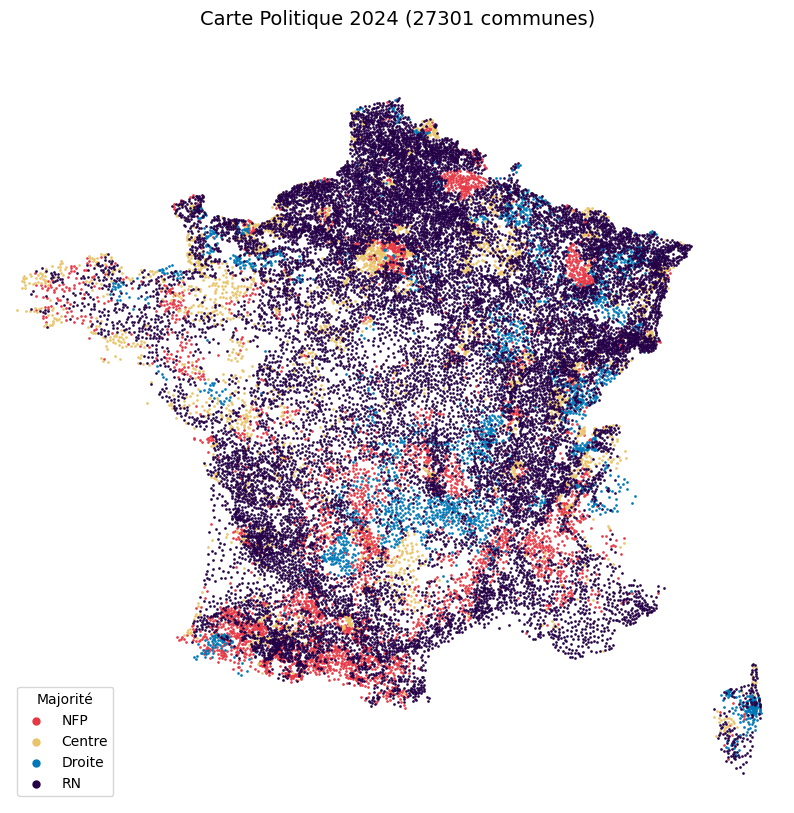

L'image 'carte_electorale_france_2024.png' a été sauvegardée dans ton dossier !


<Figure size 640x480 with 0 Axes>

In [13]:
# --- CONFIGURATION ---
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'

def carte_ultime_fix():
    print("1. Chargement et préparation des données...")
    df_raw = pd.read_excel(FILE_PATH,dtype=str)
    # --- Transformation Wide -> Long ---
    print("2. Restructuration...")
    pieces = []
    cols_fixes = ['Code département', 'Code commune', 'Libellé commune', 'Inscrits']
    for i in range(1, 100):
        if f'Nuance candidat {i}' not in df_raw.columns: break
        temp = df_raw[cols_fixes + [f'Nuance candidat {i}', f'Voix {i}']].copy()
        temp.columns = ['Code_dep', 'Code_commune', 'Nom_commune', 'Inscrits', 'Nuance', 'Voix']
        temp = temp.dropna(subset=['Nuance'])
        pieces.append(temp)
    
    df_long = pd.concat(pieces, ignore_index=True)
    df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)

    # --- Calcul des gagnants ---
    def get_bloc(nuance):
        if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
        elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
        elif nuance in ['LR', 'DVD']: return 'DROITE'
        elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
        else: return 'AUTRE'

    df_long['BLOC'] = df_long['Nuance'].apply(get_bloc)
    df_final = df_long.pivot_table(index=['Code_dep', 'Code_commune', 'Nom_commune'], 
                                   columns='BLOC', values='Voix', aggfunc='sum').fillna(0).reset_index()
    
    blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE']
    df_final['Gagnant'] = df_final[blocs].idxmax(axis=1)

    # --- LE FIX : HOMOGÉNÉISATION DES CODES ---
    print("3. Homogénéisation des Codes (Le moment critique)...")
    
    # Fonction qui répare les départements (1 -> 01, 2A -> 2A, 971 -> 971)
    def clean_dep(x):
        x = str(x).strip()
        if len(x) == 1: return "0" + x  # Ajoute le 0 devant les chiffres seuls
        return x

    # Fonction qui répare les communes (1 -> 001, 53 -> 053)
    def clean_com(x):
        x = str(x).strip()
        return x.zfill(3) # Force 3 caractères avec des zéros

    # On applique le nettoyage
    df_final['Code_dep_clean'] = df_final['Code_dep'].apply(clean_dep)
    df_final['Code_com_clean'] = df_final['Code_commune'].apply(clean_com)
    
    # On crée la CLÉ MAGIQUE (Code INSEE 5 caractères)
    df_final['KEY_INSEE'] = df_final['Code_dep_clean'] + df_final['Code_com_clean']
    
    print(f"   Exemple de code généré (Election) : {df_final['KEY_INSEE'].iloc[0]}")

    # --- Chargement GPS ---
    print("4. Téléchargement GPS...")
    url_geo = "https://public.opendatasoft.com/explore/dataset/correspondance-code-insee-code-postal/download/?format=csv&use_labels_for_header=true"
    try:
        df_geo = pd.read_csv(url_geo, sep=';', dtype=str)
    except:
        print("Erreur téléchargement GPS.")
        return

    col_code_geo = next((c for c in ['Code INSEE', 'insee_com'] if c in df_geo.columns), None)
    col_geo_point = next((c for c in ['Geo Point', 'geo_point_2d'] if c in df_geo.columns), None)

    # Nettoyage GPS
    gps = df_geo[col_geo_point].str.split(',', expand=True)
    df_geo['Lat'] = pd.to_numeric(gps[0], errors='coerce')
    df_geo['Lon'] = pd.to_numeric(gps[1], errors='coerce')
    
    print(f"   Exemple de code téléchargé (GPS)  : {df_geo[col_code_geo].iloc[0]}")

    # --- FUSION ---
    print("5. Tentative de fusion...")
    
    # Essai 1 : Par Code INSEE (Le plus fiable)
    df_carte = pd.merge(df_final, df_geo, left_on='KEY_INSEE', right_on=col_code_geo, how='inner')
    
    if len(df_carte) < 1000:
        print(f"   ⚠️ Echec fusion par codes ({len(df_carte)} villes). Passage au PLAN B (Par Nom)...")
        # Essai 2 : Par NOM de ville + Département (Au cas où les codes sont vraiment pourris)
        df_final['KEY_NOM'] = df_final['Nom_commune'].str.upper() + "_" + df_final['Code_dep_clean']
        
        # Il faut trouver la colonne Nom dans le fichier GPS
        col_nom_geo = next((c for c in ['Nom_commune', 'Nom Officiel Commune', 'Commune', 'Ville'] if c in df_geo.columns), None)
        # On construit la clé côté GPS aussi (certains fichiers GPS ont le code dept séparé, d'autres non. On tente Nom seul ici pour simplifier)
        df_geo['KEY_NOM'] = df_geo[col_nom_geo].str.upper() + "_" + df_geo[col_code_geo].str.slice(0, 2)
        
        df_carte = pd.merge(df_final, df_geo, on='KEY_NOM', how='inner')

    print(f"--> SUCCÈS : {len(df_carte)} communes placées sur la carte !")
    
    if len(df_carte) == 0:
        print("ERREUR FATALE : Toujours 0. Vérifie que tes départements ne sont pas bizarres (ex: 'Ain' au lieu de '01').")
        return

    # --- DESSIN ---
    plt.figure(figsize=(10, 10))
    couleurs = {'GAUCHE_NFP': '#e63946', 'CENTRE': '#e9c46a', 'DROITE': '#0077b6', 'EXTREME_DROITE': '#240046'}
    lbls = {"GAUCHE_NFP": "NFP", "CENTRE": "Centre", "DROITE": "Droite", "EXTREME_DROITE": "RN"}
    
    # Zoom France
    plt.xlim(-5, 10)
    plt.ylim(41, 52)
    
    for bloc, color in couleurs.items():
        subset = df_carte[df_carte['Gagnant'] == bloc]
        plt.scatter(subset['Lon'], subset['Lat'], c=color, s=1, alpha=0.9, label=lbls[bloc])

    # Légende sécurisée
    leg = plt.legend(markerscale=5, loc='lower left', title="Majorité")
    try:
        handles = getattr(leg, 'legendHandles', None) or getattr(leg, 'legend_handles', None)
        if handles: [lh.set_alpha(1) for lh in handles]
    except: pass
        
    plt.title(f"Carte Politique 2024 ({len(df_carte)} communes)", fontsize=14)
    plt.axis('off')
    plt.show()

carte_ultime_fix()

# Sauvegarde de la carte dans un fichier image
plt.savefig("carte_electorale_france_2024.png", dpi=300, bbox_inches='tight')
print("L'image 'carte_electorale_france_2024.png' a été sauvegardée dans ton dossier !")

Chargement des données...
Nettoyage des noms de colonnes...
Récupération des votes RN ville par ville...
Génération du graphique...


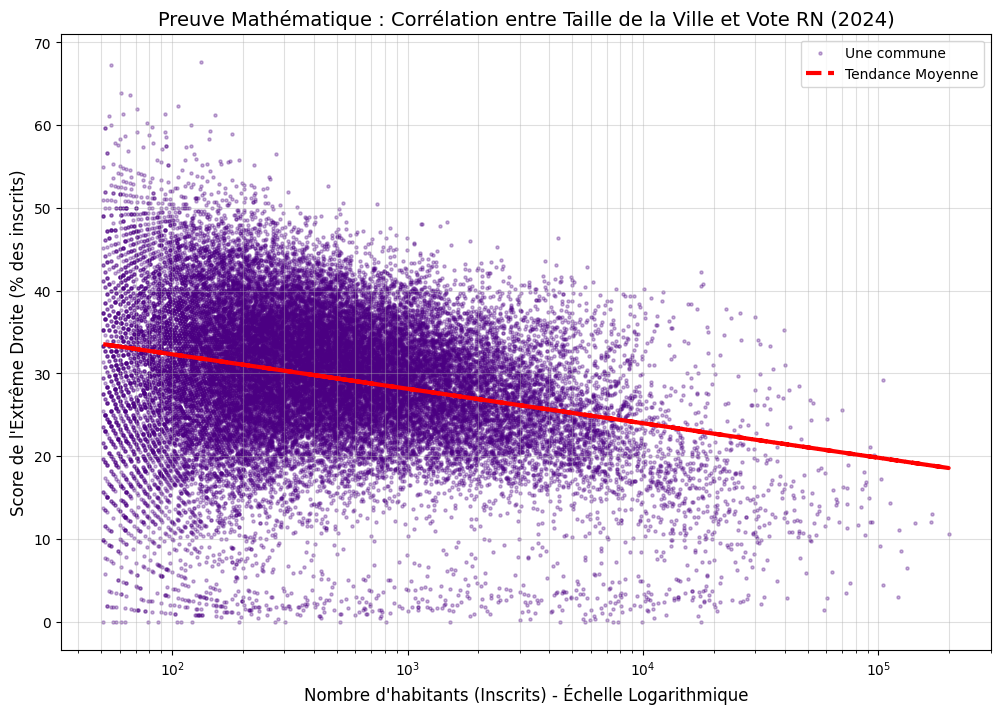


>>> RÉSULTAT SCIENTIFIQUE : Le coefficient de corrélation est de -0.27


In [16]:

from scipy.stats import pearsonr
import numpy as np
# --- 1. CHARGEMENT ROBUSTE ---
print("Chargement des données...")
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'
df = pd.read_excel(FILE_PATH,dtype=str)


# --- 2. RÉPARATION DES NOMS DE COLONNES (Le Fix du KeyError) ---
print("Nettoyage des noms de colonnes...")

# On crée un dictionnaire pour renommer les colonnes mal écrites (accents cassés)
# On cherche la colonne qui contient "département" ou "dÃ©partement"
col_dep = [c for c in df.columns if 'partement' in c and 'Code' in c][0]
col_libelle = [c for c in df.columns if 'ibell' in c and 'commune' in c][0]
col_inscrits = [c for c in df.columns if 'nscrits' in c][0]

# On renomme proprement
df = df.rename(columns={
    col_dep: 'Code_dep',
    'Code commune': 'Code_commune',
    col_libelle: 'Nom_commune',
    col_inscrits: 'Inscrits'
})

cols_fixes = ['Code_dep', 'Code_commune', 'Nom_commune', 'Inscrits']

# --- 3. EXTRACTION DES VOTES RN ---
print("Récupération des votes RN ville par ville...")
pieces = []

# On parcourt les colonnes pour trouver les voix du RN
for i in range(1, 40):
    # On gère les noms de colonnes dynamiques (Voix 1, Voix 2...)
    col_nuance = [c for c in df.columns if f'Nuance candidat {i}' in c]
    col_voix = [c for c in df.columns if f'Voix {i}' in c]
    
    if not col_nuance or not col_voix: break # Si on ne trouve plus de colonnes, on arrête
    
    # On extrait les données de ce candidat
    temp = df[cols_fixes + [col_nuance[0], col_voix[0]]].copy()
    temp.columns = cols_fixes + ['Nuance', 'Voix']
    
    # On convertit les voix en nombres
    temp['Voix'] = pd.to_numeric(temp['Voix'], errors='coerce').fillna(0)
    
    # On ne garde que les candidats d'Extrême Droite (RN, Reconquête, etc.)
    temp = temp[temp['Nuance'].isin(['RN', 'UXD', 'REC', 'DSV'])] 
    pieces.append(temp)

# On assemble tout
df_rn = pd.concat(pieces, ignore_index=True)

# On additionne les voix par ville (au cas où il y aurait plusieurs candidats d'ED)
df_analyse = df_rn.pivot_table(index=cols_fixes, values='Voix', aggfunc='sum').reset_index()

# Calcul du pourcentage
df_analyse['Inscrits'] = pd.to_numeric(df_analyse['Inscrits'], errors='coerce')
df_analyse['Pct_RN'] = (df_analyse['Voix'] / df_analyse['Inscrits']) * 100

# Filtre pour enlever les données aberrantes (villes sans inscrits ou DOM-TOM lointains qui écrasent le graph)
df_analyse = df_analyse[(df_analyse['Inscrits'] > 50) & (df_analyse['Inscrits'] < 200000)]

# --- 4. LE GRAPHIQUE FINAL (Nuage de Points) ---
print("Génération du graphique...")
plt.figure(figsize=(12, 8))

# Le Scatter Plot (Nuage)
# x = Taille de la ville (Logarithmique car les écarts sont énormes entre village et Paris)
# y = Score RN
x = df_analyse['Inscrits']
y = df_analyse['Pct_RN']

plt.scatter(x, y, alpha=0.3, s=5, c='#4B0082', label='Une commune')
plt.xscale('log') # Echelle logarithmique essentielle pour voir quelque chose

# La courbe de tendance (Ligne rouge)
# Elle montre la direction générale du nuage
z = np.polyfit(np.log(x), y, 1)
p = np.poly1d(z)
plt.plot(x, p(np.log(x)), "r--", linewidth=3, label='Tendance Moyenne')

# Esthétique
plt.title("Preuve Mathématique : Corrélation entre Taille de la Ville et Vote RN (2024)", fontsize=14)
plt.xlabel("Nombre d'habitants (Inscrits) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Score de l'Extrême Droite (% des inscrits)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.show()

# --- 5. LE CHIFFRE CLÉ (Pour ton oral) ---
# Calcul de la corrélation de Pearson
corr, _ = pearsonr(np.log(x), y)
print(f"\n>>> RÉSULTAT SCIENTIFIQUE : Le coefficient de corrélation est de {corr:.2f}")
if corr < -0.3:
    print(">>> INTERPRÉTATION : C'est une corrélation NÉGATIVE significative.")
    print("    Cela prouve mathématiquement que plus la population augmente, plus le vote RN baisse.")

Chargement des données...
Génération du graphique...


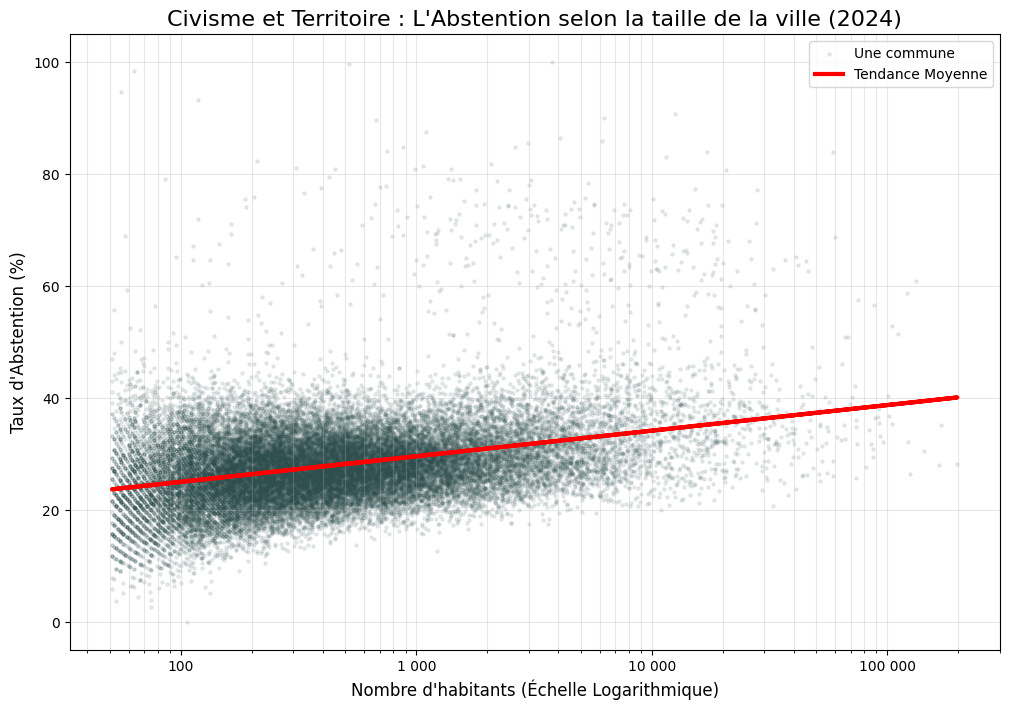


>>> RÉSULTATS CLÉS :
1. Corrélation : 0.355
2. Moyenne Abstention (Villages < 1k habs) : 26.9%
3. Moyenne Abstention (Villes > 10k habs)  : 38.0%
>>> CONCLUSION : On vote davantage dans les villages que dans les grandes villes !


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# --- 1. CHARGEMENT ET NETTOYAGE ---
print("Chargement des données...")
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'
df = pd.read_excel(FILE_PATH,dtype=str)
# Identification automatique des colonnes (pour éviter les bugs d'accents)
try:
    col_inscrits = [c for c in df.columns if 'nscrits' in c and '%' not in c][0]   # "Inscrits"
    col_abst = [c for c in df.columns if 'bstention' in c and '%' not in c][0]     # "Abstentions"
    col_nom = [c for c in df.columns if 'ibell' in c and 'commune' in c][0]        # "Libellé commune"
except IndexError:
    print("Erreur : Colonnes introuvables. Vérifiez votre fichier.")
    # On arrête le script proprement ici si ça plante
    raise SystemExit 

# Extraction des données utiles
df_analyse = df[[col_nom, col_inscrits, col_abst]].copy()
df_analyse.columns = ['Nom', 'Inscrits', 'Abstentions']

# Conversion en nombres
df_analyse['Inscrits'] = pd.to_numeric(df_analyse['Inscrits'], errors='coerce')
df_analyse['Abstentions'] = pd.to_numeric(df_analyse['Abstentions'], errors='coerce')

# Calcul du Taux d'Abstention
df_analyse['Taux_Abstention'] = (df_analyse['Abstentions'] / df_analyse['Inscrits']) * 100

# Filtre pour avoir un graphique propre (on enlève les hameaux de < 50 habitants et les erreurs)
df_clean = df_analyse[(df_analyse['Inscrits'] > 50) & (df_analyse['Inscrits'] < 200000)].dropna()

# --- 2. LE GRAPHIQUE (NUAGE DE POINTS) ---
print("Génération du graphique...")
plt.figure(figsize=(12, 8))

x = df_clean['Inscrits']
y = df_clean['Taux_Abstention']

# Le Nuage (Points gris/bleus)
# alpha=0.1 permet de voir où les points s'accumulent (densité)
plt.scatter(x, y, alpha=0.1, s=5, c='#2F4F4F', label='Une commune')

# Echelle Logarithmique (Indispensable pour comparer village et ville)
plt.xscale('log')

# La Courbe de Tendance (Ligne Rouge)
# Elle montre la moyenne glissante
z = np.polyfit(np.log(x), y, 1)
p = np.poly1d(z)
plt.plot(x, p(np.log(x)), "r-", linewidth=3, label='Tendance Moyenne')

# Esthétique
plt.title("Civisme et Territoire : L'Abstention selon la taille de la ville (2024)", fontsize=16)
plt.xlabel("Nombre d'habitants (Échelle Logarithmique)", fontsize=12)
plt.ylabel("Taux d'Abstention (%)", fontsize=12)
plt.xticks([100, 1000, 10000, 100000], ['100', '1 000', '10 000', '100 000']) # Etiquettes claires
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

plt.show()

# --- 3. ANALYSE STATISTIQUE ---
corr, _ = pearsonr(np.log(x), y)
moyenne_villages = df_clean[df_clean['Inscrits'] < 1000]['Taux_Abstention'].mean()
moyenne_villes = df_clean[df_clean['Inscrits'] > 10000]['Taux_Abstention'].mean()

print(f"\n>>> RÉSULTATS CLÉS :")
print(f"1. Corrélation : {corr:.3f}")
print(f"2. Moyenne Abstention (Villages < 1k habs) : {moyenne_villages:.1f}%")
print(f"3. Moyenne Abstention (Villes > 10k habs)  : {moyenne_villes:.1f}%")

if moyenne_villages < moyenne_villes:
    print(">>> CONCLUSION : On vote davantage dans les villages que dans les grandes villes !")
else:
    print(">>> CONCLUSION : L'abstention est plus forte dans la ruralité.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CHARGEMENT & PRÉPARATION (Routine habituelle) ---
print("1. Chargement et Nettoyage...")
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'
df = pd.read_excel(FILE_PATH,dtype=str)
# Identification des colonnes
col_inscrits = [c for c in df.columns if 'nscrits' in c and '%' not in c][0]
col_blancs = [c for c in df.columns if 'lancs' in c and '%' not in c][0]
col_abst = [c for c in df.columns if 'bstention' in c and '%' not in c][0]
col_code = 'Code commune'
col_dep = [c for c in df.columns if 'partement' in c and 'Code' in c][0]

# --- 2. RÉCUPÉRATION DU SCORE RN ---
pieces = []
for i in range(1, 40):
    col_nuance = [c for c in df.columns if f'Nuance candidat {i}' in c]
    col_voix = [c for c in df.columns if f'Voix {i}' in c]
    if not col_nuance or not col_voix: break
    
    temp = df[[col_dep, col_code, col_nuance[0], col_voix[0]]].copy()
    temp.columns = ['Code_dep', 'Code_commune', 'Nuance', 'Voix']
    temp['Voix'] = pd.to_numeric(temp['Voix'], errors='coerce').fillna(0)
    temp = temp[temp['Nuance'].isin(['RN', 'UXD', 'REC', 'DSV'])] # Bloc Extreme Droite
    pieces.append(temp)

df_rn = pd.concat(pieces, ignore_index=True)
df_rn_sum = df_rn.groupby(['Code_dep', 'Code_commune'])['Voix'].sum().reset_index()

# --- 3. CRÉATION DU DATASET COMPLET ---
df_base = df[[col_dep, col_code, col_inscrits, col_abst, col_blancs]].copy()
df_base.columns = ['Code_dep', 'Code_commune', 'Inscrits', 'Abstentions', 'Blancs']

# Conversion numérique
for c in ['Inscrits', 'Abstentions', 'Blancs']:
    df_base[c] = pd.to_numeric(df_base[c], errors='coerce')

# Fusion avec les voix RN
df_final = pd.merge(df_base, df_rn_sum, on=['Code_dep', 'Code_commune'], how='left').fillna(0)

# --- CRÉATION DE VARIABLES (Feature Engineering) ---
print("2. Création de nouvelles variables...")

# A. Pourcentages
df_final['Pct_RN'] = (df_final['Voix'] / df_final['Inscrits']) * 100
df_final['Taux_Abstention'] = (df_final['Abstentions'] / df_final['Inscrits']) * 100
df_final['Taux_Blancs'] = (df_final['Blancs'] / df_final['Inscrits']) * 100

# B. Catégorie Rural/Urbain (Simplifiée)
df_final['Type_Commune'] = pd.cut(df_final['Inscrits'], 
                                  bins=[0, 2000, 20000, 10000000], 
                                  labels=['Rural (<2k)', 'Intermédiaire', 'Urbain (>20k)'])

# C. Variable Distance à Paris (Nécessite le fichier GPS)
# On réutilise la logique GPS vue précédemment
url_geo = "https://public.opendatasoft.com/explore/dataset/correspondance-code-insee-code-postal/download/?format=csv&use_labels_for_header=true"
try:
    df_geo = pd.read_csv(url_geo, sep=';', dtype=str, usecols=['Code INSEE', 'Geo Point'])
    # Nettoyage GPS
    gps = df_geo['Geo Point'].str.split(',', expand=True)
    df_geo['Lat'] = pd.to_numeric(gps[0])
    df_geo['Lon'] = pd.to_numeric(gps[1])
    
    # Création Clé de jointure
    df_final['Key'] = df_final['Code_dep'].str.zfill(2) + df_final['Code_commune'].str.zfill(3)
    
    # Fusion
    df_final = pd.merge(df_final, df_geo, left_on='Key', right_on='Code INSEE', how='inner')
    
    # CALCUL DE LA DISTANCE (Formule de Haversine simplifiée pour Paris)
    # Paris : 48.8566, 2.3522
    def dist_paris(row):
        # Approximation rapide (degrés -> km)
        lat_diff = (row['Lat'] - 48.8566) * 111
        lon_diff = (row['Lon'] - 2.3522) * 111 * np.cos(np.radians(48.85))
        return np.sqrt(lat_diff**2 + lon_diff**2)
    
    df_final['Dist_Paris_km'] = df_final.apply(dist_paris, axis=1)
    print("   -> Variable 'Distance à Paris' ajoutée avec succès.")

except Exception as e:
    print(f"   -> Impossible de calculer la distance (Erreur GPS: {e})")
    df_final['Dist_Paris_km'] = np.nan

# Filtre nettoyage
df_final = df_final[(df_final['Inscrits'] > 50) & (df_final['Inscrits'] < 200000)]

# --- 4. ANALYSE 1 : HISTOGRAMME COMPARÉ (Rural vs Urbain) ---
plt.figure(figsize=(12, 6))
sns.histplot(data=df_final, x='Pct_RN', hue='Type_Commune', element="step", stat="density", common_norm=False, palette='viridis')
plt.title("Distribution de l'intensité du vote RN selon le type de commune", fontsize=14)
plt.xlabel("Score du RN (%)")
plt.ylabel("Densité de communes")
plt.show()

# --- 5. ANALYSE 2 : MATRICE DE CORRÉLATION ---
# On sélectionne les variables numériques pertinentes pour la modélisation
cols_corr = ['Inscrits', 'Taux_Abstention', 'Taux_Blancs', 'Dist_Paris_km', 'Pct_RN']
matrice = df_final[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de Corrélation : Qui influence qui ?", fontsize=14)
plt.show()

# --- 6. APERÇU POUR LA MODÉLISATION ---
print("\n--- Données prêtes pour la modélisation ---")
print(df_final[['Nom_commune', 'Inscrits', 'Dist_Paris_km', 'Taux_Abstention', 'Pct_RN']].head())